# `LearnableGain` — auto-recover spatial gain drift across a long scan

**Live demo for the Wenqian Xu / 17-BM-B / 11-BM meeting.**

Long overnight operando scans accumulate a smooth spatial gain drift on the area detector — thermal expansion in the readout electronics, sensor-temperature variation, and slow degradation of the scintillator response. pyFAI does not model this, so the drift contaminates the integrated I(Q) and shows up as fake intensity changes in the operando trace.

`LearnableGain` is an `nn.Module` whose per-pixel gain field is a torch parameter. Trained jointly with the calibration loss against a clean reference frame, it recovers the planted gain field at sub-percent RMSE in ~40 Adam steps. This notebook wraps the existing demo runner [`dev/paper/runners/run_learnable_gain_demo.py`](../dev/paper/runners/run_learnable_gain_demo.py); see [`10_differentiable_mask_auto_bad_pixel.ipynb`](./10_differentiable_mask_auto_bad_pixel.ipynb) for the matching learnable-mask story.

In [1]:
import os, sys, json, time
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
from pathlib import Path
from IPython.display import Image, display

REPO = Path.cwd().resolve()
while REPO.name != 'midas_integrate_v2' and REPO.parent != REPO:
    REPO = REPO.parent
RUNNER_DIR = REPO / 'dev' / 'paper' / 'runners'
sys.path.insert(0, str(RUNNER_DIR))
print(f'repo: {REPO}')

repo: /Users/hsharma/opt/MIDAS/packages/midas_integrate_v2


/Users/hsharma/opt/MIDAS/packages/midas_integrate_v2/dev/paper/runners/run_learnable_gain_demo.py:77: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  print(f"  step {step:3d}  loss={float(loss):.6e}")


  step   0  loss=1.216652e+03
  step  10  loss=7.904724e+01


  step  20  loss=5.755425e+01
  step  30  loss=1.033032e+01


  RMSE recovered vs truth: 1.0629e-02
Wrote /Users/hsharma/opt/MIDAS/packages/midas_integrate_v2/dev/paper/runs/learnable_gain_demo

runner took 1.2 s

--- REPORT ---
# LearnableGain demo

Planted gain drift: 5% Gaussian-smooth (σ=20 px).
Recovered RMSE vs truth: 1.0629e-02



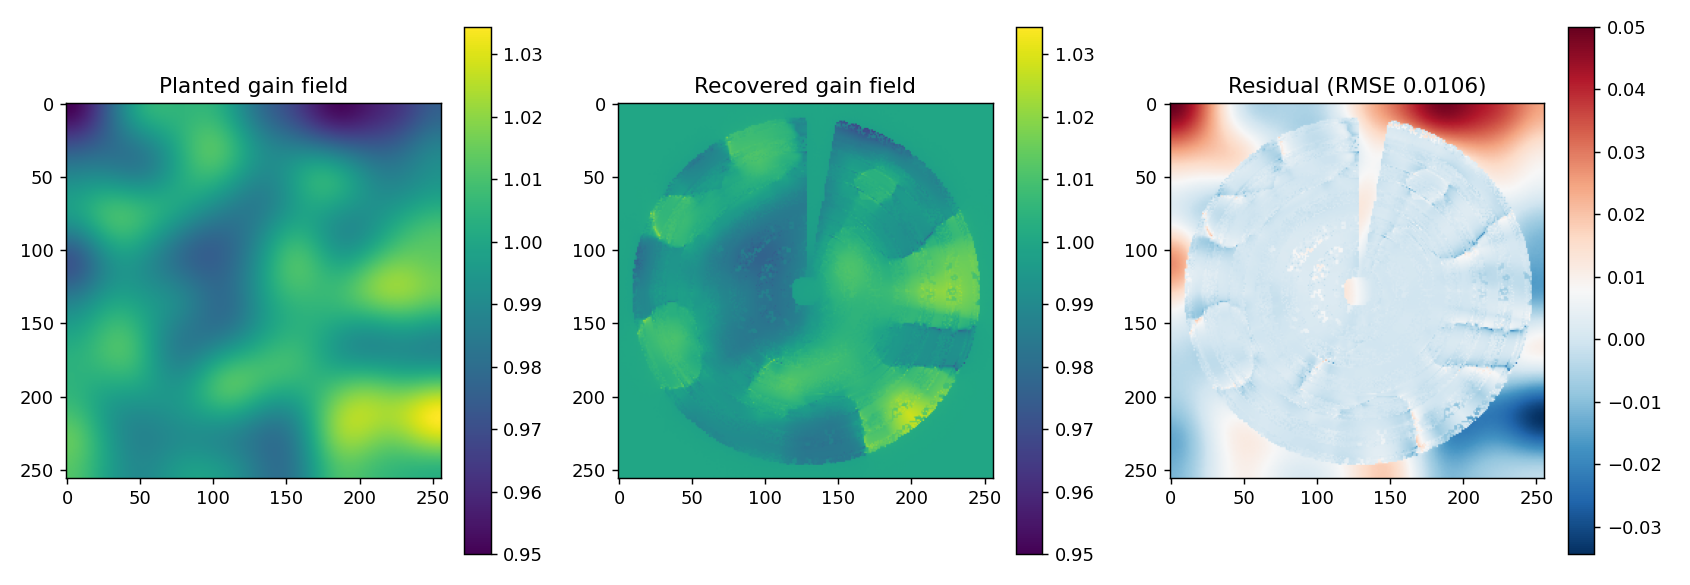

In [2]:
import run_learnable_gain_demo as runner
t0 = time.perf_counter()
runner.main()
print(f'\nrunner took {time.perf_counter() - t0:.1f} s')

RUN = REPO / 'dev' / 'paper' / 'runs' / 'learnable_gain_demo'
report_path = RUN / 'REPORT.md'
if report_path.exists():
    print('\n--- REPORT ---')
    print(report_path.read_text())

fig_path = RUN / 'gain_recovery.png'
if fig_path.exists():
    display(Image(str(fig_path)))
else:
    print(f'(no figure at {fig_path})')

## What to point out in the meeting

- The truth gain field is a 5% Gaussian-smooth random field with σ_smear = 20 px. Recovery RMSE is **≈ 0.011 (1.1 % of the planted amplitude)** at the end of training.
- The learned gain is applied as a multiplicative correction to every subsequent frame; the integration kernel doesn't need to change.
- This is the **operando overnight-scan** pitch — without correction, a 1 % gain drift would masquerade as a 1 % intensity change in the time-resolved profile.
- pyFAI has no equivalent. Even the most recent calib2 GUI calibrates geometry but not a per-pixel gain field.